In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import pandas as pd

print(os.getcwd())

PATH = os.getcwd()

print(os.listdir(PATH))

import matplotlib as mpl

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["cmr10", "DejaVu Serif", "serif"],
    "axes.formatter.use_mathtext": True,
    "font.size": 12
})

/home/andre/Documents/Git/LoveBombing/notebook
['log.txt', 'dados.csv', 'main.ipynb', 'img', '.ipynb_checkpoints', 'vazaoManual_30s.csv', 'dados_sem_outliers.csv', 'Data.csv', 'dadosBancada.txt']


# Potência,Tensão,Vazão

In [2]:
file = PATH + "/dadosBancada.txt"

dt = pd.read_csv(file, sep=';', index_col=False)

print(dt.head())

bomba = "bomba(%)"
bomba = dt[bomba]
tensao = "tensao(V)"
tensao = dt[tensao]
vazao = "vazao(l/min)"
vazao = dt[vazao]

   bomba(%)  tensao(V)  vazao(l/min)
0         0      0.000          0.00
1        10      0.453          0.00
2        15      0.910          0.00
3        20      1.397          0.00
4        25      2.253          0.35


## Tensão x PWM(%)

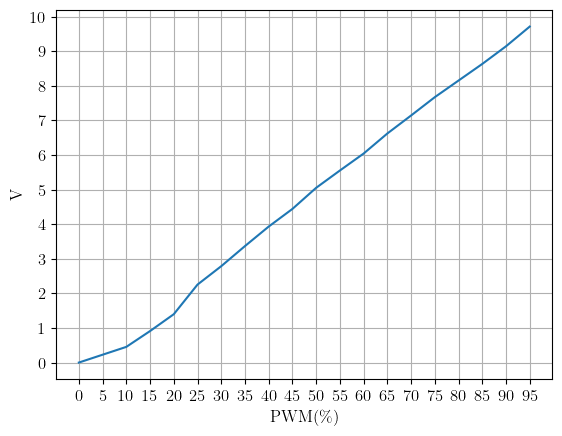

In [3]:
plt.plot(bomba, tensao)

plt.grid()
# plt.title(r"Bomba (\%) x Tensao(V)")
plt.xlabel(r"PWM($\%$)")
plt.ylabel("V")
plt.xticks(np.arange(0,100, step=5))
plt.yticks(np.arange(0,11, step=1))

plt.savefig("./img/bombaTensaoXPWM.pdf")

plt.show()

### Regressão linear entre Tensão x PWM(%)

A = 0.107292
B = -0.429335
erro: 0.02367620106768258
rmse: 0.1538707284303372


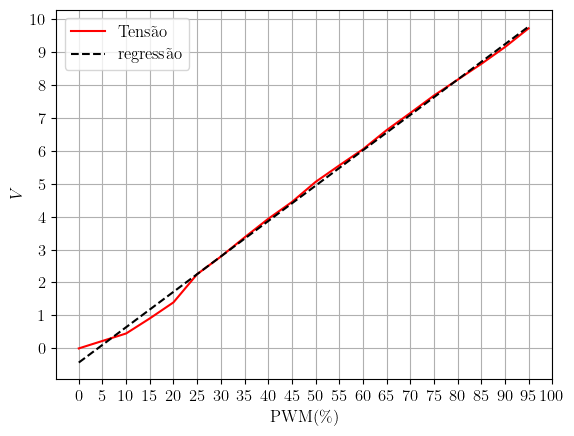

In [8]:
def modelo(x,A,B):
    return A*x + B

# Chute inicial para os parâmetros
p0 = [1, 0.03]

# Ajuste
param, cov = curve_fit(modelo, bomba, tensao, p0=p0)

Atensao, Btensao = param

print(f"A = {Atensao:.6f}")
print(f"B = {Btensao:.6f}")

x_plot = np.linspace(min(bomba), max(bomba), 300)
y_plot = modelo(x_plot, *param)

# Erro quadratico médio
erro = tensao - (Atensao*bomba + Btensao)
eqm = np.mean(np.square(erro))
rmse = np.sqrt(np.mean(erro**2))
print(f'erro: {eqm}')
print(f'rmse: {rmse}')

plt.plot(bomba, tensao, label="Tensão", color='red')
plt.plot(x_plot, y_plot, label="regressão", linestyle='--', color='black')

plt.grid()
plt.legend()
plt.xlabel(r"PWM($\%$)")
plt.ylabel(r"$V$")
plt.xticks(np.arange(0,105,5))
plt.yticks(np.arange(0,11,1))

plt.savefig("./img/TensaoXPWM_regressao.pdf")

plt.show()

## Tensão x Vazão (L/min)

In [ ]:
plt.plot(bomba, vazao)

plt.grid()
plt.title(r"Bomba (\%) x Vazão($L/min$)")
plt.xlabel("%")
plt.ylabel("V")
plt.xticks(np.arange(0,100, step=5))
plt.yticks(np.arange(0,2.6, step=0.25))

plt.show()

# Pulsos, Potêcia

In [ ]:
file = PATH + "/dados.csv"
    
MinSamples = 752
MaxSamples = 3000

df = pd.read_csv(
    file,
    header=None,
    names=[
        "pulso_us",
        "pulso_ms",
        "duty",
        "duty_percent"
    ],
    sep='\t'
)

print(df.head())

pulsosus = "pulso_us"
pulsosus = df[pulsosus][MinSamples:MaxSamples]
pulsosms = "pulso_ms"
pulsosms = df[pulsosms][MinSamples:MaxSamples]
duty = "duty"
duty = df[duty][MinSamples:MaxSamples]
dutypercent = "duty_percent"
dutypercent = df[dutypercent][MinSamples:MaxSamples]

plt.plot(dutypercent, pulsosms)
plt.xticks(np.arange(0,110,10))
plt.yticks(np.arange(0,14,1))
plt.grid()

plt.show()


## Pulso médio (ms) x PWM (%)

In [ ]:
# Modelo exponencial com assíntota
def modelo(x, A, B, C):
    return A * np.exp(-B * x) + C

# Limita a quantidade de amostras
df = df.iloc[MinSamples:MaxSamples]

# Calcula a média do pulso para cada PWM (%)
media = (
    df.groupby("duty_percent", as_index=False)["pulso_ms"]
      .mean()
      .sort_values("duty_percent")
)

# Chute inicial para os parâmetros
p0 = [10, 0.03, 1]

# Ajuste
param, cov = curve_fit(modelo, media["duty_percent"], media["pulso_ms"], p0=p0)

Apwm, Bpwm, Cpwm = param

print(f"A = {Apwm:.6f}")
print(f"B = {Bpwm:.6f}")
print(f"C = {Cpwm:.6f}")

x_plot = np.linspace(min(media["duty_percent"]), max(media["duty_percent"]), 300)
y_plot = modelo(x_plot, *param)

# Gráfico
plt.figure(figsize=(6,4))

plt.plot(
    media["duty_percent"],
    media["pulso_ms"],
    marker='o',
    linewidth=2,
    label="usn-hs41ta"
)

plt.plot(x_plot, y_plot, label='Ajuste')

# plt.title(r"Média dos pulsos em $ms$")
plt.xlabel(r"PWM ($\%$)")
plt.ylabel(r"Pulso médio (ms)")
plt.legend()

plt.xticks(np.arange(25, 110, 5))
plt.yticks(np.arange(0, 6, 0.5))

plt.grid(True)

plt.savefig("./img/ajustePeriodo.pdf")

plt.show()

## Pulso médio (ms) x Vazão (L/min)

In [ ]:
# Modelo exponencial crescente com assíntota
def modelo(x, A, B, C):
    return A*np.exp(-B*x)+C

mediaPulsos_ms = media["pulso_ms"].to_numpy()

vazao_ls = np.array([
    0.350, 0.606, 1.050, 1.372,
    1.422, 1.794, 2.014, 2.188, 2.225
])

# Chute inicial
p0 = [2.5, 1.0, 2.5]

# Ajuste
param, cov = curve_fit(
    modelo,
    mediaPulsos_ms,
    vazao_ls,
    p0=p0
)

Al_min, Bl_min, Cl_min = param

print(f"A = {Al_min:.6f}")
print(f"B = {Bl_min:.6f}")
print(f"C = {Cl_min:.6f}")

# R²
y_pred = modelo(mediaPulsos_ms, *param)

ss_res = np.sum((vazao_ls - y_pred)**2)
ss_tot = np.sum((vazao_ls - np.mean(vazao_ls))**2)
r2 = 1 - ss_res/ss_tot

print(f"R² = {r2:.5f}")

# Gráfico
x_plot = np.linspace(mediaPulsos_ms.min(), mediaPulsos_ms.max(), 500)
y_plot = modelo(x_plot, *param)

plt.figure(figsize=(6,4))
plt.scatter(mediaPulsos_ms, vazao_ls, label="Dados")
# plt.plot(x_plot, y_plot, 'r', label=f"Ajuste (R²={r2:.4f})")
plt.plot(x_plot, y_plot, 'r', label=f"Ajuste")

plt.xlabel("Largura do pulso (ms)")
plt.ylabel("Vazão (L/s)")
plt.grid(True)
plt.legend()

plt.savefig("./img/ajusteVazao.pdf")

plt.show()

In [ ]:
bomba = 70
ms = Apwm * np.exp(-Bpwm*bomba) + Cpwm
vz = Al_min*np.exp(-Bl_min*ms) + Cl_min

print(ms,vz)

# Teste de Vazão mássica

In [ ]:
file = PATH + '/vazaoManual_30s.csv'

data = pd.read_csv(file, sep=';')

print(data.head)

deltaT = 'deltaT(s)'
deltaT = data[deltaT]
bomba ='bomba(%)'
bomba = data[bomba]
massa = 'massa(g)'
massa = data[massa]
recipiente = 'recipiente(g)'
recipiente = data[recipiente]

massa = massa - recipiente

g_por_L = 1000 # g/L

vazao_g_por_min = massa / deltaT * 60
vazao_L_por_min = vazao_g_por_min / g_por_L

plt.subplot(211)
plt.title('Potência x Massa')
plt.plot(bomba, massa, ls='-.')

plt.grid()
plt.xlabel(r'bomba($\%$)')
plt.ylabel('$g$')

plt.subplot(212)

plt.plot(bomba, vazao_L_por_min)

plt.grid()
plt.xlabel(r"bomba($\%$)")
plt.ylabel(r"$L/min$")

plt.show()